In [5]:
import contextlib
import io
import logging
import sys
import warnings
from pathlib import Path
from textwrap import fill

project_root = Path.cwd()
venv_candidates = sorted((project_root / ".venv_ts" / "lib").glob("python*/site-packages"))
for candidate in venv_candidates:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy.stats import norm
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pandas.tseries.offsets import MonthBegin

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    try:
        from prophet import Prophet
    except Exception:
        Prophet = None

if Prophet is None:
    raise ImportError(
        "Prophet is unavailable. Activate the local '.venv_ts' interpreter or install prophet into your active kernel."
    )

sns.set_theme(style="whitegrid", context="talk")

BG = "#f6fbff"
PANEL = "#ffffff"
INK = "#102a43"
MUTED = "#627d98"
GRID = "#d9e2ec"
NAVY = "#0f4c81"
SKY = "#4ea8de"
TEAL = "#2a9d8f"
AMBER = "#f4a261"
CORAL = "#e76f51"
ROSE = "#d62839"
SLATE = "#334e68"
MIST = "#eaf4fc"

MODEL_COLORS = {
    "Prophet": NAVY,
    "SARIMAX": TEAL,
    "ETS": AMBER,
    "LightGBM": CORAL,
}

MARKET_PALETTE = {
    "APAC": "#0f4c81",
    "Africa": "#1b6ca8",
    "Canada": "#63b3ed",
    "EMEA": "#2a9d8f",
    "EU": "#5fb49c",
    "LATAM": "#f4a261",
    "US": "#e76f51",
}

DEMAND_CMAP = LinearSegmentedColormap.from_list(
    "demand_cmap",
    ["#eef6fd", "#6baed6", "#0f4c81"],
)
RESIDUAL_CMAP = LinearSegmentedColormap.from_list(
    "residual_cmap",
    [ROSE, "#fefefe", TEAL],
)

plt.rcParams.update(
    {
        "figure.facecolor": BG,
        "axes.facecolor": PANEL,
        "savefig.facecolor": BG,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK,
        "axes.titlecolor": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "text.color": INK,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "grid.alpha": 0.8,
        "font.family": "DejaVu Sans",
        "axes.titlepad": 16,
    }
)

MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
MODEL_ORDER = ["Prophet", "SARIMAX", "ETS", "LightGBM"]
FORECAST_HORIZON = 6
VALIDATION_START = pd.Timestamp("2014-01-01")
TRAIN_END = pd.Timestamp("2013-12-01")


def currency_fmt(x, pos=None):
    sign = "-" if x < 0 else ""
    x = abs(float(x))
    if x >= 1_000_000:
        return f"{sign}${x / 1_000_000:.1f}M"
    if x >= 1_000:
        return f"{sign}${x / 1_000:.0f}K"
    return f"{sign}${x:,.0f}"


def pct_fmt(x, pos=None):
    return f"{x:.0%}"


def wrap_for_axis(ax, text, base_chars=96, minimum=30):
    width = ax.get_position().width
    char_budget = max(minimum, int(base_chars * width))
    return fill(text, width=char_budget, break_long_words=False)


def style_axis(ax, title, subtitle=None, title_size=16.5, subtitle_size=10.4):
    wrapped_title = wrap_for_axis(ax, title, base_chars=90, minimum=28)
    title_lines = wrapped_title.count("\n") + 1
    title_y = 1.11 + 0.055 * (title_lines - 1)
    ax.text(
        0,
        title_y,
        wrapped_title,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=title_size,
        fontweight="bold",
        color=INK,
        clip_on=False,
    )
    if subtitle:
        wrapped_subtitle = wrap_for_axis(ax, subtitle, base_chars=120, minimum=40)
        ax.text(
            0,
            title_y - 0.02,
            wrapped_subtitle,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=subtitle_size,
            color=MUTED,
            clip_on=False,
        )


def finalize_figure(fig, top=0.9, bottom=0.1, left=0.07, right=0.97):
    fig.subplots_adjust(top=top, bottom=bottom, left=left, right=right)


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    return 100 * np.mean(np.where(denom == 0, 0, 2 * np.abs(y_pred - y_true) / denom))


def coverage_rate(actual, lower, upper):
    actual = np.asarray(actual, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)
    return np.mean((actual >= lower) & (actual <= upper))


def make_lag_frame(series):
    frame = pd.DataFrame({"y": series.astype(float)})
    for lag in [1, 2, 3, 6, 12]:
        frame[f"lag_{lag}"] = frame["y"].shift(lag)
    for win in [3, 6]:
        frame[f"roll_mean_{win}"] = frame["y"].shift(1).rolling(win).mean()
        frame[f"roll_std_{win}"] = frame["y"].shift(1).rolling(win).std()
    frame["month"] = frame.index.month
    frame["quarter"] = frame.index.quarter
    frame["time_idx"] = np.arange(len(frame))
    frame["month_sin"] = np.sin(2 * np.pi * frame["month"] / 12)
    frame["month_cos"] = np.cos(2 * np.pi * frame["month"] / 12)
    return frame.dropna()


def make_feature_row(history, ds):
    return pd.DataFrame(
        [
            {
                "lag_1": history.iloc[-1],
                "lag_2": history.iloc[-2],
                "lag_3": history.iloc[-3],
                "lag_6": history.iloc[-6],
                "lag_12": history.iloc[-12],
                "roll_mean_3": history.iloc[-3:].mean(),
                "roll_std_3": history.iloc[-3:].std(),
                "roll_mean_6": history.iloc[-6:].mean(),
                "roll_std_6": history.iloc[-6:].std(),
                "month": ds.month,
                "quarter": ds.quarter,
                "time_idx": len(history),
                "month_sin": np.sin(2 * np.pi * ds.month / 12),
                "month_cos": np.cos(2 * np.pi * ds.month / 12),
            }
        ]
    )


def forecast_prophet(train_series, periods=1, interval_width=0.8):
    train_df = train_series.rename_axis("ds").reset_index(name="y")
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        model = Prophet(
            interval_width=interval_width,
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode="multiplicative",
            changepoint_prior_scale=0.1,
        )
        model.fit(train_df)
    future = model.make_future_dataframe(periods=periods, freq="MS")
    forecast = model.predict(future).set_index("ds")[["yhat", "yhat_lower", "yhat_upper"]].tail(periods)
    forecast = forecast.rename(columns={"yhat_lower": "lower", "yhat_upper": "upper"})
    return forecast


def forecast_sarimax(train_series, periods=1, alpha=0.2):
    model = SARIMAX(
        train_series,
        order=(1, 1, 1),
        seasonal_order=(0, 1, 1, 12),
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)
    forecast_obj = model.get_forecast(periods)
    interval = forecast_obj.conf_int(alpha=alpha)
    forecast = pd.DataFrame(
        {
            "yhat": forecast_obj.predicted_mean,
            "lower": interval.iloc[:, 0],
            "upper": interval.iloc[:, 1],
        }
    )
    return forecast


def forecast_ets(train_series, periods=1, alpha=0.2):
    model = ExponentialSmoothing(
        train_series,
        trend="add",
        seasonal="mul",
        seasonal_periods=12,
        initialization_method="estimated",
    ).fit(optimized=True, use_brute=True)
    forecast_mean = model.forecast(periods)
    residuals = train_series - model.fittedvalues
    sigma = float(np.nanstd(residuals, ddof=1))
    z_score = norm.ppf(1 - alpha / 2)
    horizon = np.arange(1, periods + 1)
    band = z_score * sigma * np.sqrt(horizon)
    forecast = pd.DataFrame(
        {
            "yhat": forecast_mean.values,
            "lower": forecast_mean.values - band,
            "upper": forecast_mean.values + band,
        },
        index=forecast_mean.index,
    )
    return forecast


def forecast_lightgbm(train_series, periods=1):
    frame = make_lag_frame(train_series)
    X_train = frame.drop(columns="y")
    y_train = frame["y"]
    params = {
        "n_estimators": 250,
        "learning_rate": 0.05,
        "num_leaves": 7,
        "max_depth": 3,
        "min_child_samples": 1,
        "min_child_weight": 0,
        "min_data_in_bin": 1,
        "subsample": 1.0,
        "colsample_bytree": 1.0,
        "verbosity": -1,
        "random_state": 42,
    }
    point_model = lgb.LGBMRegressor(objective="regression", **params)
    lower_model = lgb.LGBMRegressor(objective="quantile", alpha=0.1, **params)
    upper_model = lgb.LGBMRegressor(objective="quantile", alpha=0.9, **params)
    point_model.fit(X_train, y_train)
    lower_model.fit(X_train, y_train)
    upper_model.fit(X_train, y_train)

    history = train_series.copy()
    records = []
    for step in range(periods):
        ds = history.index[-1] + MonthBegin(1)
        row = make_feature_row(history, ds)
        pred = float(point_model.predict(row)[0])
        lower = float(lower_model.predict(row)[0])
        upper = float(upper_model.predict(row)[0])
        history.loc[ds] = pred
        records.append((ds, pred, lower, upper))

    return pd.DataFrame(records, columns=["ds", "yhat", "lower", "upper"]).set_index("ds")


FORECASTERS = {
    "Prophet": forecast_prophet,
    "SARIMAX": forecast_sarimax,
    "ETS": forecast_ets,
    "LightGBM": forecast_lightgbm,
}


def blended_margin_template(monthly_frame, blend_weight=0.65):
    seasonal_margin = monthly_frame.groupby(monthly_frame.index.month)["margin"].mean()
    trailing_margin = monthly_frame["margin"].tail(12).mean()
    return blend_weight * seasonal_margin + (1 - blend_weight) * trailing_margin


def apply_margin_template(index, template):
    return np.array([template.loc[ts.month] for ts in index], dtype=float)


def add_empirical_bands(forecast_frame, pct_errors):
    spread_50 = pct_errors.abs().quantile(0.5)
    spread_80 = pct_errors.abs().quantile(0.8)
    out = forecast_frame.copy()
    out["lower_80"] = np.maximum(0, out["yhat"] * (1 - spread_80))
    out["upper_80"] = np.maximum(0, out["yhat"] * (1 + spread_80))
    out["lower_50"] = np.maximum(0, out["yhat"] * (1 - spread_50))
    out["upper_50"] = np.maximum(0, out["yhat"] * (1 + spread_50))
    return out


def plot_fan(ax, history, forecast, color, title, subtitle):
    ax.plot(history.index, history.values, color=SLATE, linewidth=2.2, label="History")
    ax.fill_between(
        forecast.index,
        forecast["lower_80"],
        forecast["upper_80"],
        color=color,
        alpha=0.12,
        label="80% interval",
    )
    ax.fill_between(
        forecast.index,
        forecast["lower_50"],
        forecast["upper_50"],
        color=color,
        alpha=0.26,
        label="50% interval",
    )
    ax.plot(forecast.index, forecast["yhat"], color=color, linewidth=2.6, marker="o", label="Forecast")
    ax.axvline(history.index.max(), color=MUTED, linestyle="--", linewidth=1.2)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=35)
    ax.set_xlabel("")
    ax.set_ylabel("")
    style_axis(ax, title, subtitle, title_size=15.3, subtitle_size=10.1)

In [6]:
candidate_paths = [
    Path("/content/SuperStoreOrders - SuperStoreOrders.csv"),
    Path("SuperStoreOrders - SuperStoreOrders.csv"),
    Path("../SuperStoreOrders - SuperStoreOrders.csv"),
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not locate 'SuperStoreOrders - SuperStoreOrders.csv' from the current working directory.")

df = pd.read_csv(DATA_PATH)
df["sales"] = pd.to_numeric(df["sales"].astype(str).str.replace(",", "", regex=False))
df["profit"] = pd.to_numeric(df["profit"])
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True)

monthly = (
    df.groupby(pd.Grouper(key="order_date", freq="MS"))
    .agg(sales=("sales", "sum"), profit=("profit", "sum"))
    .sort_index()
)
monthly["margin"] = monthly["profit"] / monthly["sales"]
monthly["rolling_3m"] = monthly["sales"].rolling(3, min_periods=1).mean()
monthly["rolling_12m"] = monthly["sales"].rolling(12, min_periods=3).mean()

market_monthly = (
    df.groupby([pd.Grouper(key="order_date", freq="MS"), "market"])
    .agg(sales=("sales", "sum"), profit=("profit", "sum"))
    .reset_index()
    .rename(columns={"order_date": "ds"})
    .sort_values(["market", "ds"])
)
market_monthly["margin"] = market_monthly["profit"] / market_monthly["sales"]

market_wide = market_monthly.pivot(index="ds", columns="market", values="sales").fillna(0)
markets = market_wide.columns.tolist()

seasonal_index = market_monthly.copy()
seasonal_index["month_name"] = pd.Categorical(seasonal_index["ds"].dt.strftime("%b"), categories=MONTH_ORDER, ordered=True)
seasonal_index["market_mean"] = seasonal_index.groupby("market")["sales"].transform("mean")
seasonal_index["demand_index"] = seasonal_index["sales"] / seasonal_index["market_mean"]
seasonal_heatmap = (
    seasonal_index.groupby(["market", "month_name"], observed=False)["demand_index"]
    .mean()
    .unstack("month_name")
    .reindex(index=markets, columns=MONTH_ORDER)
)

summary = pd.DataFrame(
    {
        "item": [
            "Series start",
            "Series end",
            "Monthly observations",
            "Forecast horizon",
            "Training window",
            "Validation window",
            "Markets forecasted",
        ],
        "value": [
            str(monthly.index.min().date()),
            str(monthly.index.max().date()),
            f"{len(monthly):,}",
            f"{FORECAST_HORIZON} months",
            "2011-01 to 2013-12",
            "2014-01 to 2014-12",
            f"{len(markets):,}",
        ],
    }
)

display(summary)
display(pd.DataFrame({"dataset_path": [str(DATA_PATH.resolve())]}))

,item,value
0,Series start,2011-01-01
1,Series end,2014-12-01
2,Monthly observations,48
3,Forecast horizon,6 months
4,Training window,2011-01 to 2013-12
5,Validation window,2014-01 to 2014-12
6,Markets forecasted,7


,dataset_path
0,/content/SuperStoreOrders - SuperStoreOrders.csv


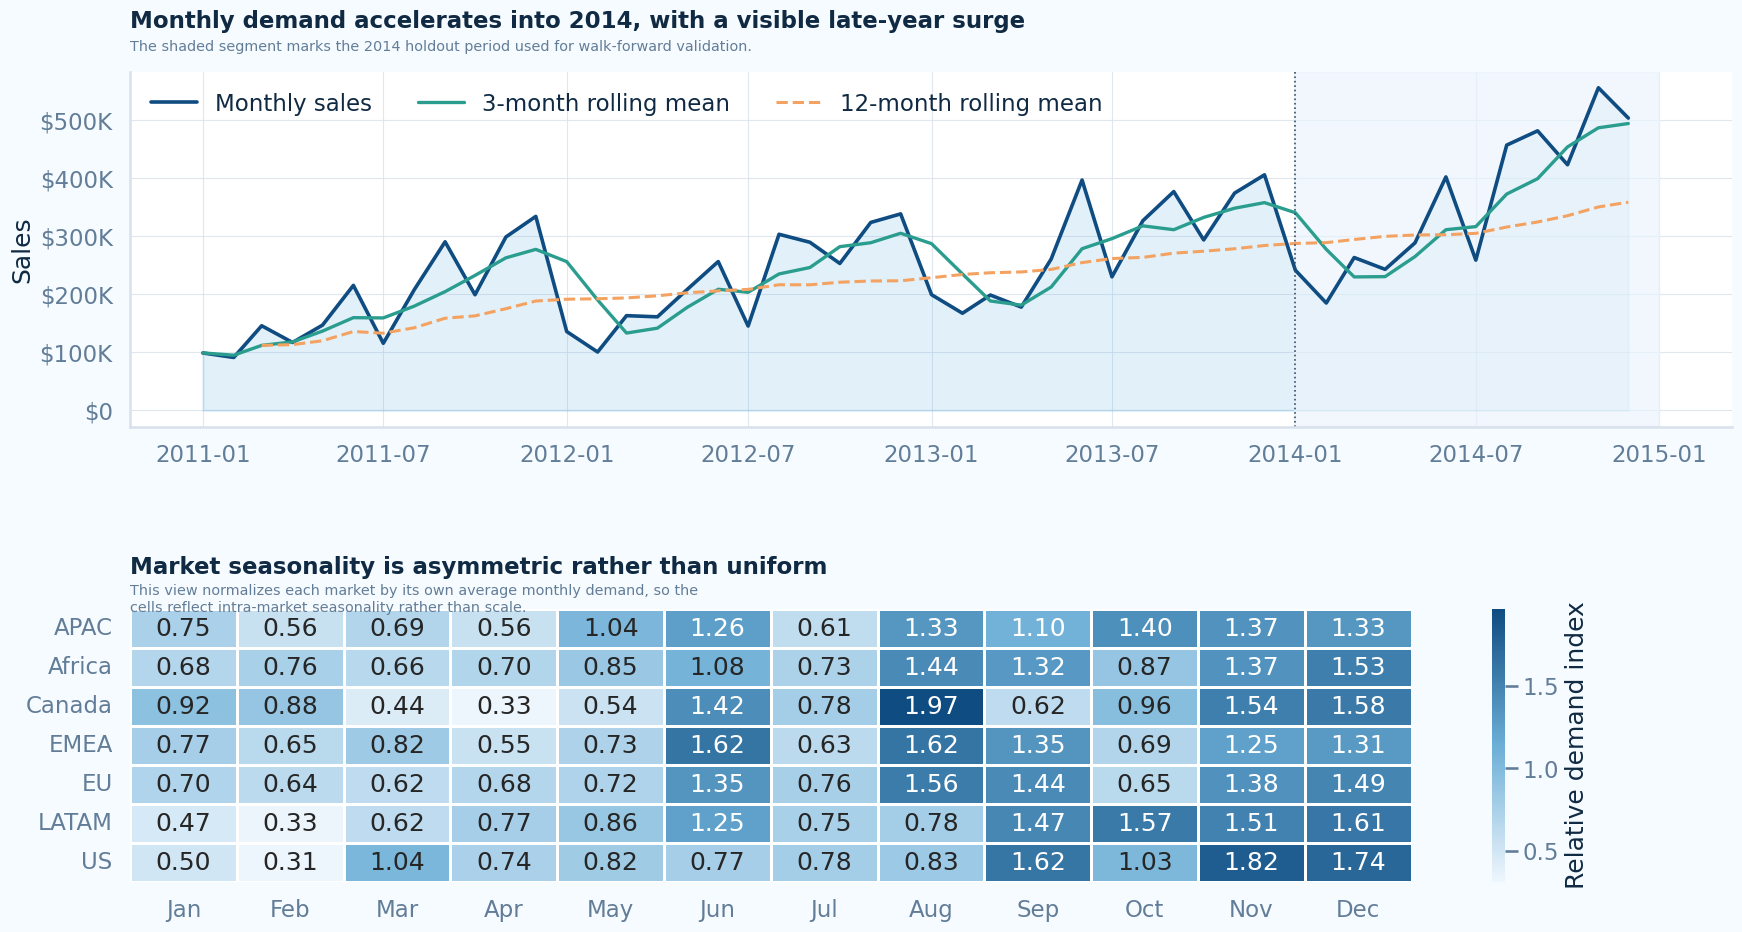

In [7]:
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[1.3, 1], hspace=0.58)

ax_top = fig.add_subplot(gs[0, 0])
ax_top.fill_between(monthly.index, monthly["sales"], color=SKY, alpha=0.16)
ax_top.plot(monthly.index, monthly["sales"], color=NAVY, linewidth=2.6, label="Monthly sales")
ax_top.plot(monthly.index, monthly["rolling_3m"], color=TEAL, linewidth=2.4, label="3-month rolling mean")
ax_top.plot(monthly.index, monthly["rolling_12m"], color=AMBER, linewidth=2.2, linestyle="--", label="12-month rolling mean")
ax_top.axvspan(VALIDATION_START, monthly.index.max() + MonthBegin(1), color=MIST, alpha=0.65)
ax_top.axvline(VALIDATION_START, color=SLATE, linewidth=1.2, linestyle=":")
style_axis(
    ax_top,
    "Monthly demand accelerates into 2014, with a visible late-year surge",
    "The shaded segment marks the 2014 holdout period used for walk-forward validation.",
)
ax_top.set_ylabel("Sales")
ax_top.yaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
ax_top.legend(frameon=False, loc="upper left", ncol=3)

ax_heat = fig.add_subplot(gs[1, 0])
sns.heatmap(
    seasonal_heatmap,
    ax=ax_heat,
    cmap=DEMAND_CMAP,
    annot=True,
    fmt=".2f",
    linewidths=1,
    cbar_kws={"label": "Relative demand index"},
)
style_axis(
    ax_heat,
    "Market seasonality is asymmetric rather than uniform",
    "This view normalizes each market by its own average monthly demand, so the cells reflect intra-market seasonality rather than scale.",
)
ax_heat.set_xlabel("")
ax_heat.set_ylabel("")

finalize_figure(fig, top=0.92, bottom=0.11, left=0.08, right=0.97)
plt.show()

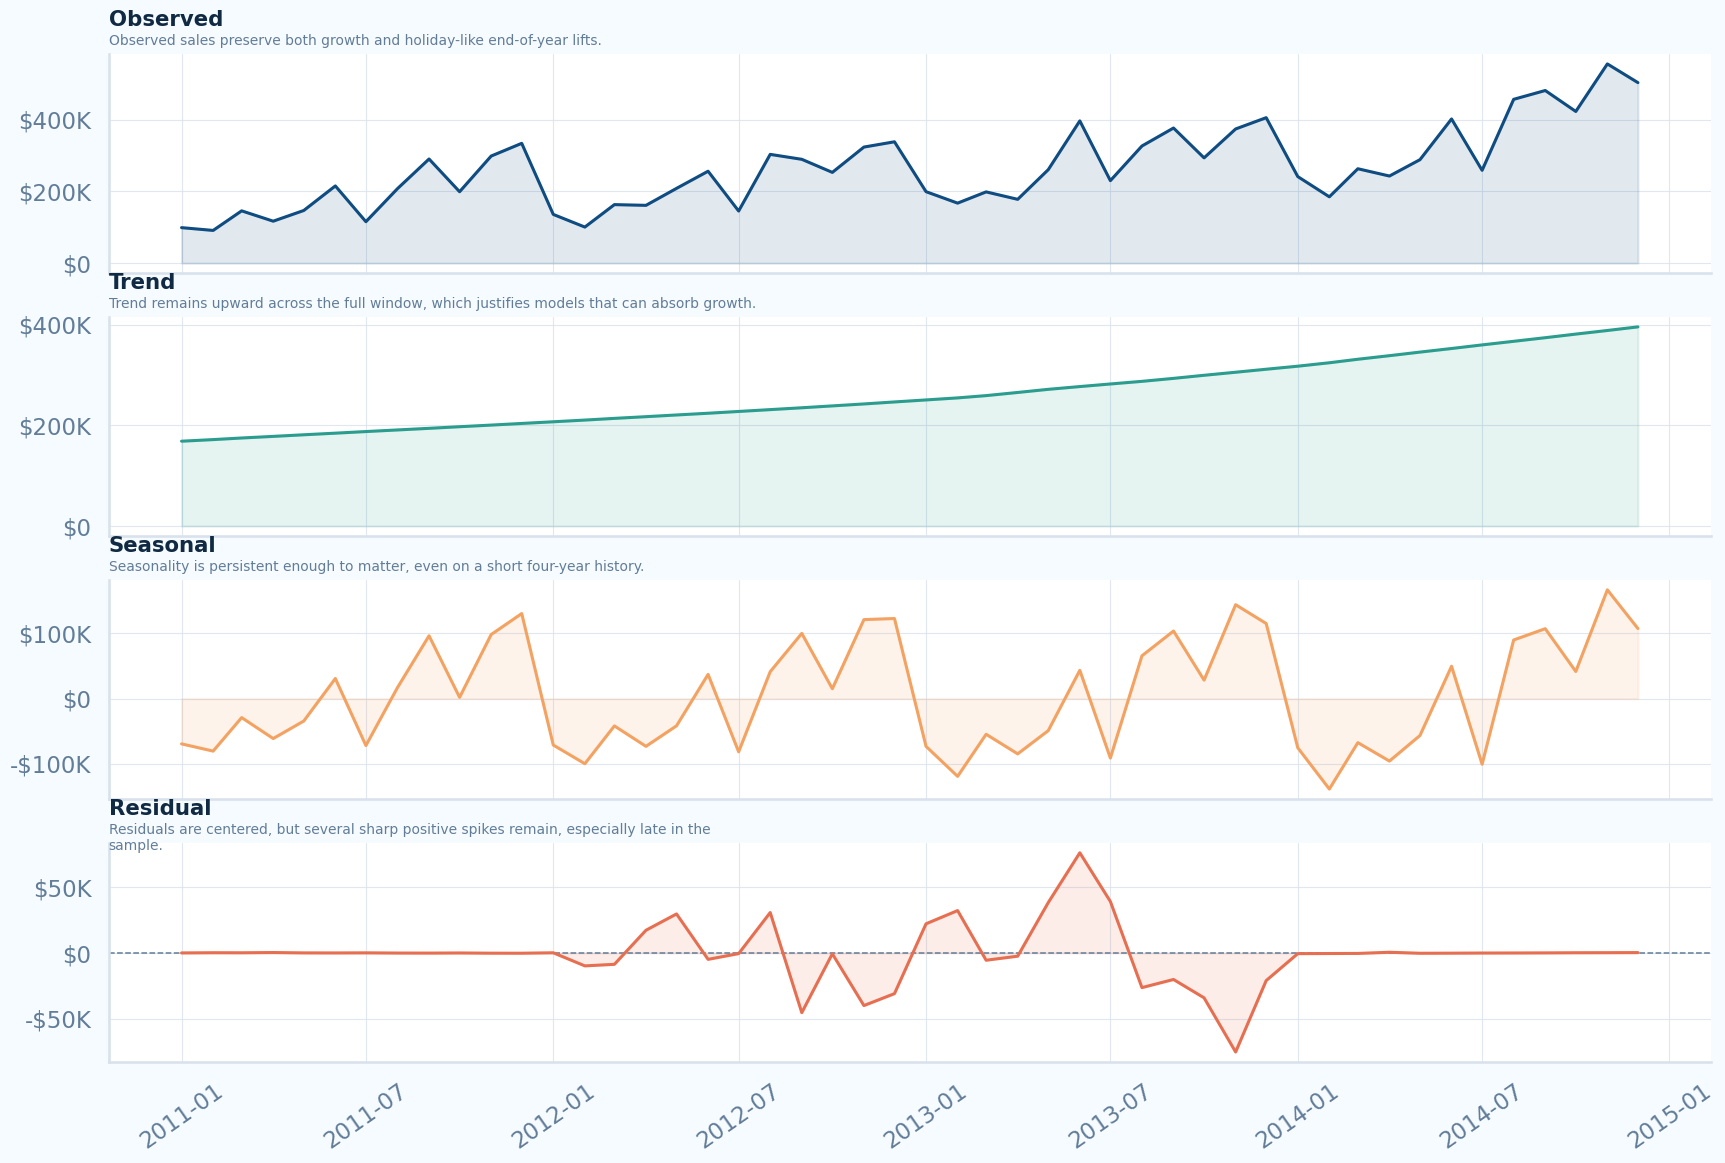

In [8]:
stl_result = STL(monthly["sales"], period=12, robust=True).fit()
stl_frame = pd.DataFrame(
    {
        "Observed": monthly["sales"],
        "Trend": stl_result.trend,
        "Seasonal": stl_result.seasonal,
        "Residual": stl_result.resid,
    }
)

fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)
component_specs = [
    ("Observed", NAVY, "Observed sales preserve both growth and holiday-like end-of-year lifts."),
    ("Trend", TEAL, "Trend remains upward across the full window, which justifies models that can absorb growth."),
    ("Seasonal", AMBER, "Seasonality is persistent enough to matter, even on a short four-year history."),
    ("Residual", CORAL, "Residuals are centered, but several sharp positive spikes remain, especially late in the sample."),
]

for ax, (component, color, subtitle) in zip(axes, component_specs):
    series = stl_frame[component]
    if component == "Residual":
        ax.axhline(0, color=MUTED, linestyle="--", linewidth=1.1)
    ax.plot(series.index, series.values, color=color, linewidth=2.2)
    ax.fill_between(series.index, 0, series.values, color=color, alpha=0.12)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
    style_axis(ax, component, subtitle, title_size=15.3, subtitle_size=10.0)
    ax.set_ylabel("")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].tick_params(axis="x", rotation=35)

finalize_figure(fig, top=0.94, bottom=0.1, left=0.08, right=0.97)
plt.show()

In [9]:
validation_dates = monthly.loc[VALIDATION_START:].index
comparison_records = []

for current_date in validation_dates:
    train_series = monthly.loc[: current_date - MonthBegin(1), "sales"]
    actual_value = float(monthly.loc[current_date, "sales"])
    for model_name in MODEL_ORDER:
        forecast = FORECASTERS[model_name](train_series, periods=1)
        row = forecast.iloc[0]
        comparison_records.append(
            {
                "date": current_date,
                "model": model_name,
                "actual": actual_value,
                "pred": float(row["yhat"]),
                "lower": float(row["lower"]),
                "upper": float(row["upper"]),
            }
        )

comparison_df = pd.DataFrame(comparison_records)
comparison_df["error"] = comparison_df["actual"] - comparison_df["pred"]
comparison_df["pct_error"] = comparison_df["error"] / comparison_df["pred"]
comparison_df["abs_error"] = comparison_df["error"].abs()

comparison_metrics = (
    comparison_df.groupby("model")
    .apply(
        lambda g: pd.Series(
            {
                "MAE": mean_absolute_error(g["actual"], g["pred"]),
                "RMSE": np.sqrt(mean_squared_error(g["actual"], g["pred"])),
                "sMAPE": smape(g["actual"], g["pred"]),
                "Coverage80": coverage_rate(g["actual"], g["lower"], g["upper"]),
            }
        )
    )
    .round(2)
    .sort_values("sMAPE")
)

champion_model = comparison_metrics.index[0]
champion_validation = comparison_df.loc[comparison_df["model"] == champion_model].copy()
prophet_validation = comparison_df.loc[comparison_df["model"] == "Prophet"].copy()

display(comparison_metrics)

,MAE,RMSE,sMAPE,Coverage80
model,,,,
Prophet,33463.13,45757.88,8.88,0.33
SARIMAX,35331.76,43220.10,9.79,0.83
ETS,37794.94,43865.30,10.85,0.42
LightGBM,50715.15,61532.85,14.65,0.25


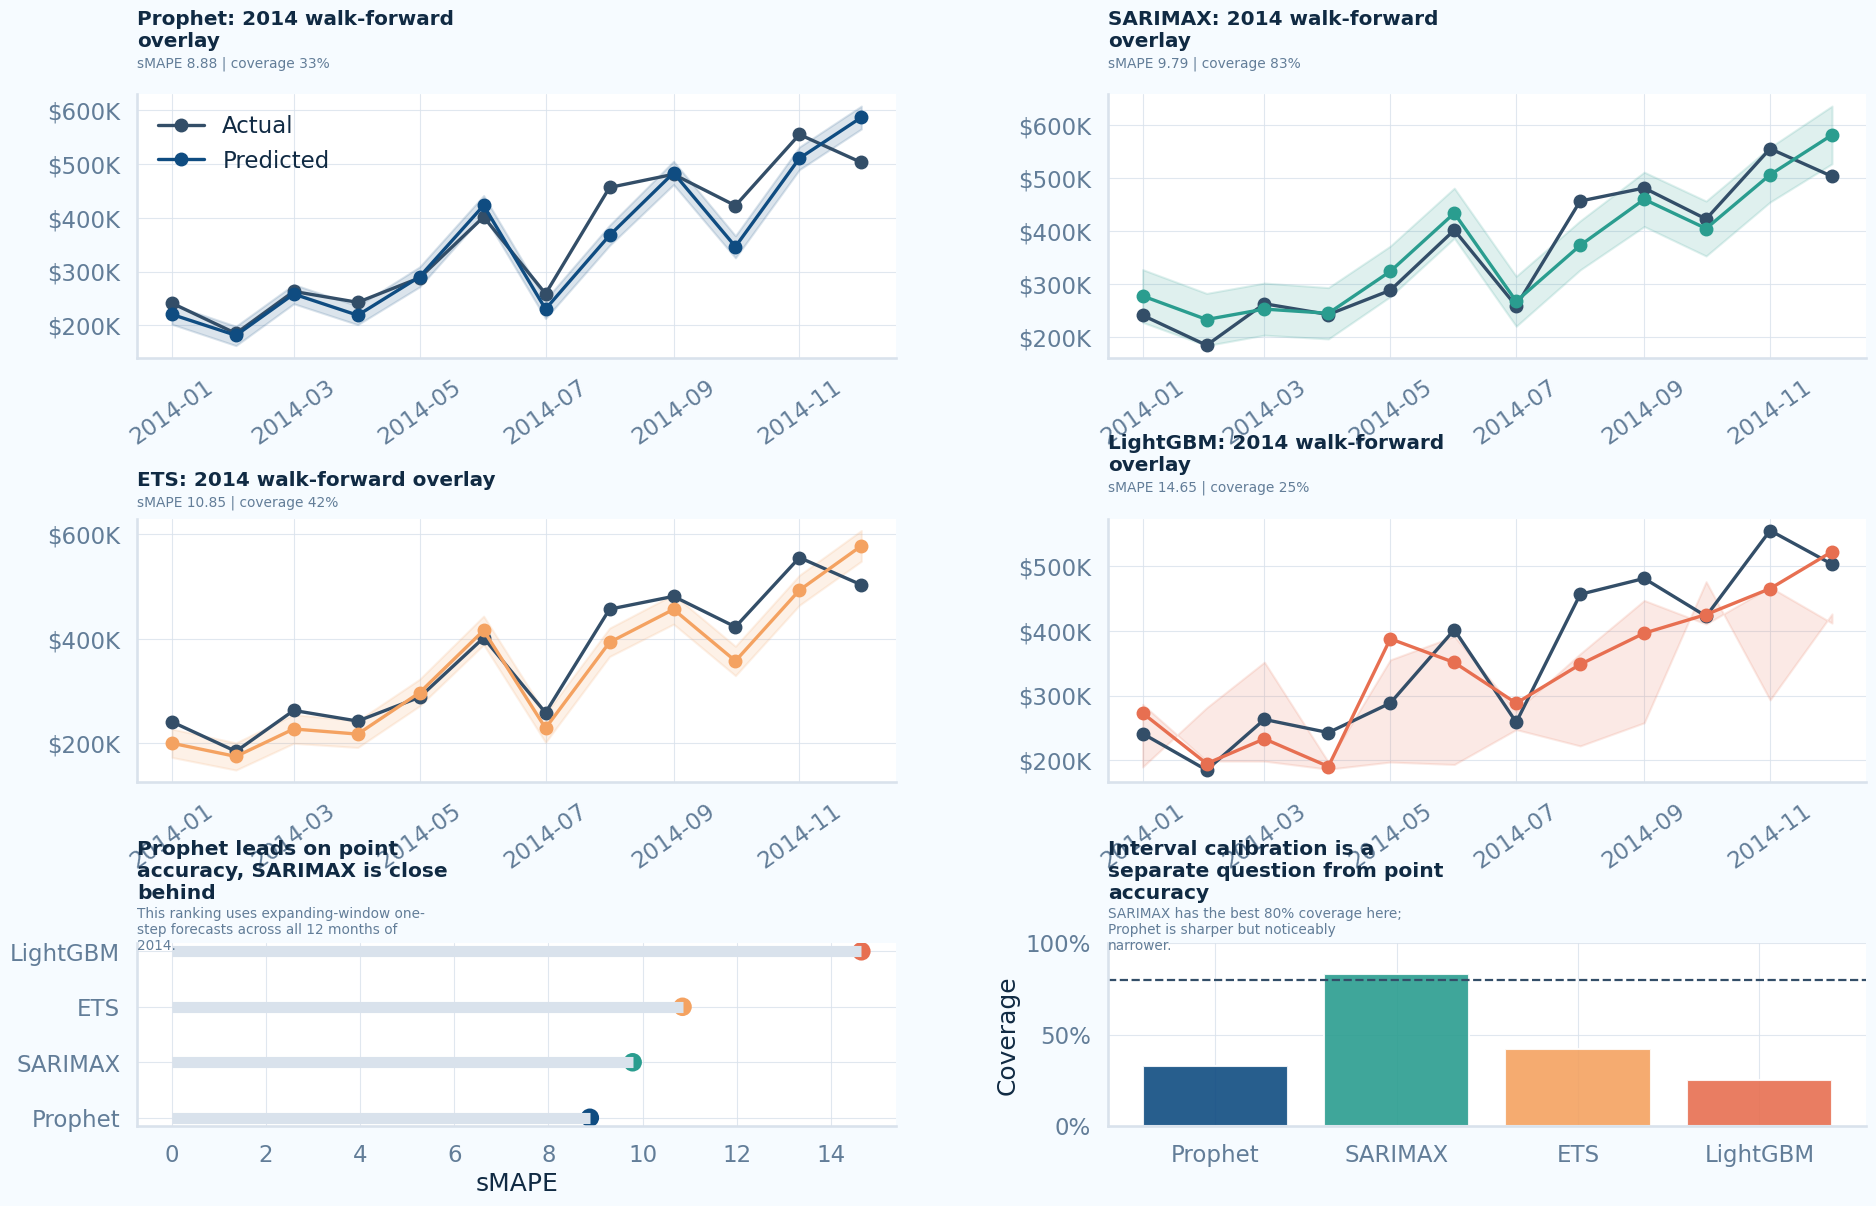

In [10]:
fig = plt.figure(figsize=(19, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1.18, 1.18, 0.82], hspace=0.68, wspace=0.28)

for i, model_name in enumerate(MODEL_ORDER):
    ax = fig.add_subplot(gs[i // 2, i % 2])
    data = comparison_df.loc[comparison_df["model"] == model_name].copy()
    color = MODEL_COLORS[model_name]
    ax.fill_between(data["date"], data["lower"], data["upper"], color=color, alpha=0.15)
    ax.plot(data["date"], data["actual"], color=SLATE, linewidth=2.4, marker="o", label="Actual")
    ax.plot(data["date"], data["pred"], color=color, linewidth=2.4, marker="o", label="Predicted")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=35)
    style_axis(
        ax,
        f"{model_name}: 2014 walk-forward overlay",
        f"sMAPE {comparison_metrics.loc[model_name, 'sMAPE']:.2f} | coverage {comparison_metrics.loc[model_name, 'Coverage80']:.0%}",
        title_size=14.4,
        subtitle_size=9.9,
    )
    if i == 0:
        ax.legend(frameon=False, loc="upper left")

ax_metric = fig.add_subplot(gs[2, 0])
metric_plot = comparison_metrics.reset_index()
ax_metric.hlines(metric_plot["model"], 0, metric_plot["sMAPE"], color=GRID, linewidth=8)
ax_metric.scatter(metric_plot["sMAPE"], metric_plot["model"], s=140, color=[MODEL_COLORS[m] for m in metric_plot["model"]])
ax_metric.set_xlabel("sMAPE")
ax_metric.set_ylabel("")
style_axis(
    ax_metric,
    "Prophet leads on point accuracy, SARIMAX is close behind",
    "This ranking uses expanding-window one-step forecasts across all 12 months of 2014.",
    title_size=14.6,
    subtitle_size=9.8,
)
ax_metric.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f"))

ax_cov = fig.add_subplot(gs[2, 1])
ax_cov.bar(metric_plot["model"], metric_plot["Coverage80"], color=[MODEL_COLORS[m] for m in metric_plot["model"]], alpha=0.9)
ax_cov.axhline(0.8, color=SLATE, linestyle="--", linewidth=1.6)
ax_cov.set_ylim(0, 1.0)
ax_cov.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
style_axis(
    ax_cov,
    "Interval calibration is a separate question from point accuracy",
    "SARIMAX has the best 80% coverage here; Prophet is sharper but noticeably narrower.",
    title_size=14.6,
    subtitle_size=9.8,
)
ax_cov.set_xlabel("")
ax_cov.set_ylabel("Coverage")

finalize_figure(fig, top=0.95, bottom=0.09, left=0.06, right=0.97)
plt.show()

,value
Profit MAE,7736.10
Profit RMSE,9701.39
Profit sMAPE,17.79


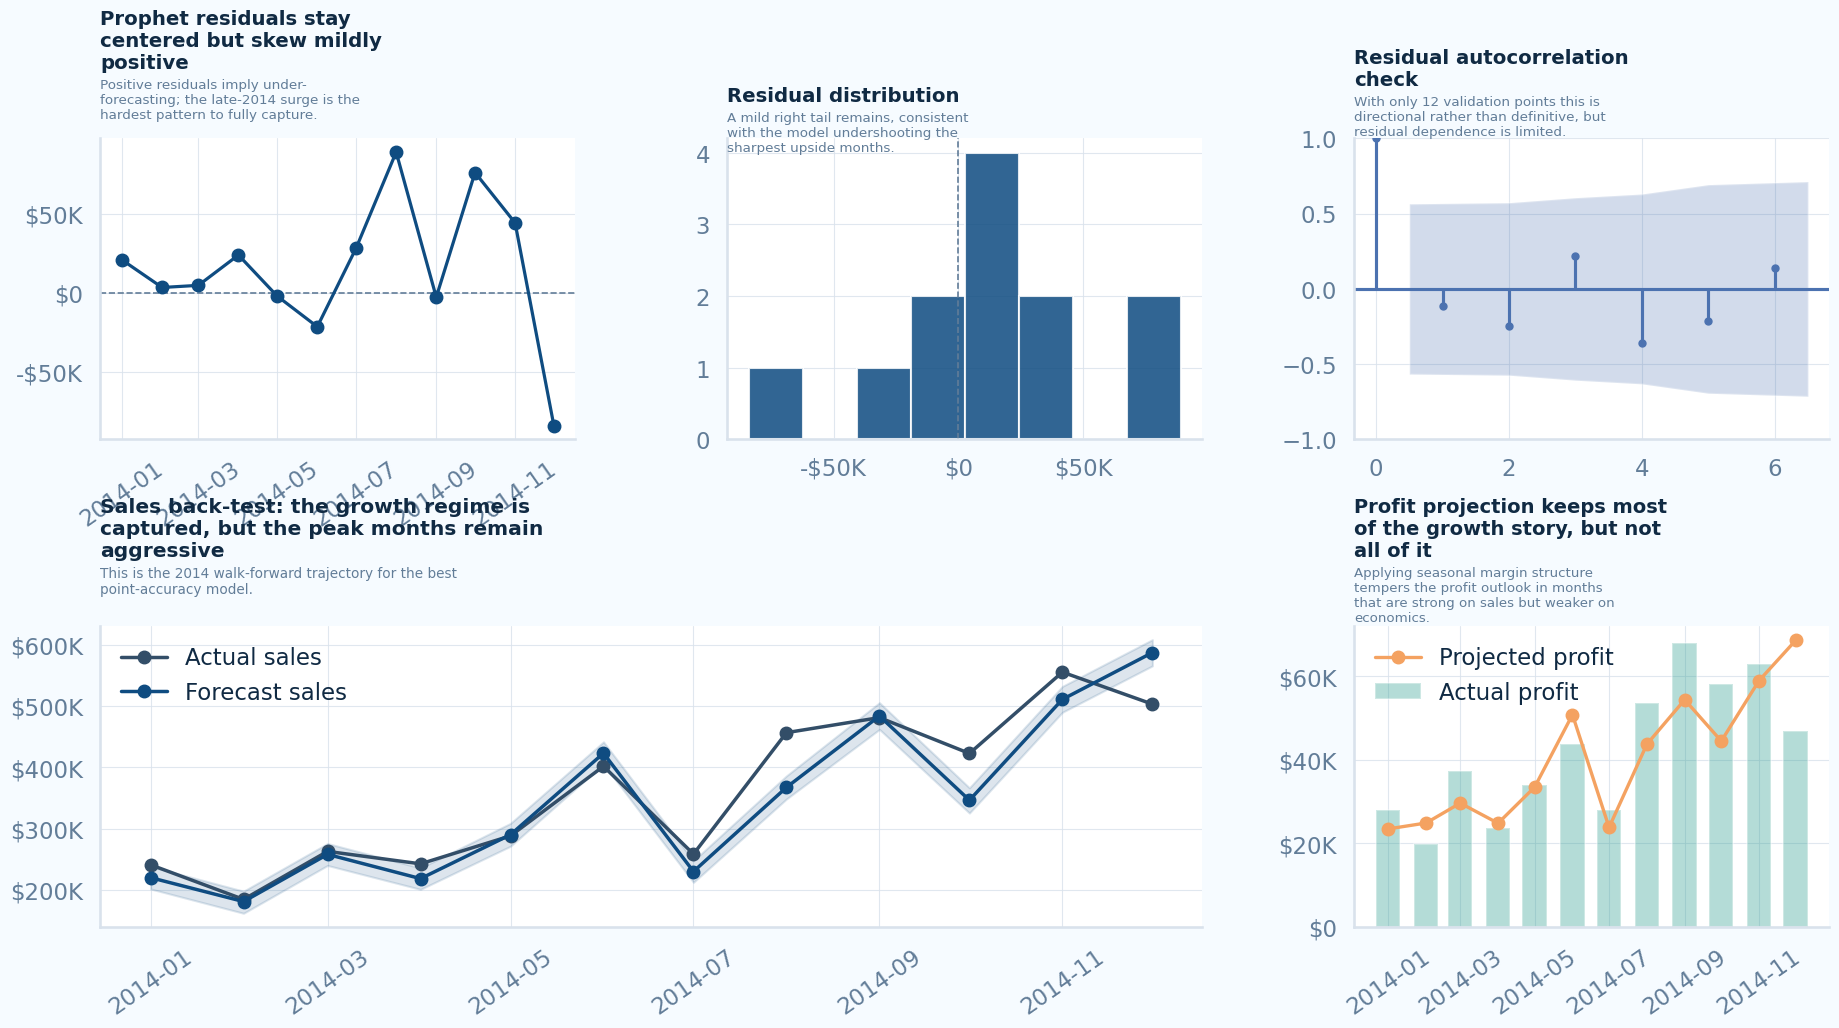

In [11]:
margin_template_train = blended_margin_template(monthly.loc[:TRAIN_END, ["sales", "profit", "margin"]])
champion_validation["projected_profit"] = champion_validation["pred"] * apply_margin_template(champion_validation["date"], margin_template_train)
champion_validation["actual_profit"] = monthly.loc[champion_validation["date"], "profit"].values

profit_metrics = pd.Series(
    {
        "Profit MAE": mean_absolute_error(champion_validation["actual_profit"], champion_validation["projected_profit"]),
        "Profit RMSE": np.sqrt(mean_squared_error(champion_validation["actual_profit"], champion_validation["projected_profit"])),
        "Profit sMAPE": smape(champion_validation["actual_profit"], champion_validation["projected_profit"]),
    }
).round(2)

display(profit_metrics.to_frame("value"))

fig = plt.figure(figsize=(19, 9.5))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.62, wspace=0.32)

ax_resid = fig.add_subplot(gs[0, 0])
ax_resid.axhline(0, color=MUTED, linestyle="--", linewidth=1.2)
ax_resid.plot(champion_validation["date"], champion_validation["error"], color=MODEL_COLORS[champion_model], linewidth=2.3, marker="o")
ax_resid.yaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
ax_resid.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax_resid.tick_params(axis="x", rotation=35)
style_axis(
    ax_resid,
    f"{champion_model} residuals stay centered but skew mildly positive",
    "Positive residuals imply under-forecasting; the late-2014 surge is the hardest pattern to fully capture.",
    title_size=14.2,
    subtitle_size=9.7,
)

ax_hist = fig.add_subplot(gs[0, 1])
ax_hist.hist(champion_validation["error"], bins=8, color=MODEL_COLORS[champion_model], alpha=0.86, edgecolor=PANEL)
ax_hist.axvline(0, color=MUTED, linestyle="--", linewidth=1.2)
ax_hist.xaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
style_axis(
    ax_hist,
    "Residual distribution",
    "A mild right tail remains, consistent with the model undershooting the sharpest upside months.",
    title_size=14.2,
    subtitle_size=9.7,
)

ax_acf = fig.add_subplot(gs[0, 2])
plot_acf(champion_validation["error"], ax=ax_acf, lags=6, title="")
style_axis(
    ax_acf,
    "Residual autocorrelation check",
    "With only 12 validation points this is directional rather than definitive, but residual dependence is limited.",
    title_size=14.2,
    subtitle_size=9.7,
)

ax_sales = fig.add_subplot(gs[1, :2])
ax_sales.plot(champion_validation["date"], champion_validation["actual"], color=SLATE, linewidth=2.5, marker="o", label="Actual sales")
ax_sales.plot(champion_validation["date"], champion_validation["pred"], color=MODEL_COLORS[champion_model], linewidth=2.5, marker="o", label="Forecast sales")
ax_sales.fill_between(champion_validation["date"], champion_validation["lower"], champion_validation["upper"], color=MODEL_COLORS[champion_model], alpha=0.14)
ax_sales.yaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
ax_sales.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax_sales.tick_params(axis="x", rotation=35)
style_axis(
    ax_sales,
    "Sales back-test: the growth regime is captured, but the peak months remain aggressive",
    "This is the 2014 walk-forward trajectory for the best point-accuracy model.",
    title_size=14.6,
    subtitle_size=9.8,
)
ax_sales.legend(frameon=False, loc="upper left")

ax_profit = fig.add_subplot(gs[1, 2])
ax_profit.bar(champion_validation["date"], champion_validation["actual_profit"], width=20, color=TEAL, alpha=0.35, label="Actual profit")
ax_profit.plot(champion_validation["date"], champion_validation["projected_profit"], color=AMBER, linewidth=2.4, marker="o", label="Projected profit")
ax_profit.yaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
ax_profit.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax_profit.tick_params(axis="x", rotation=35)
style_axis(
    ax_profit,
    "Profit projection keeps most of the growth story, but not all of it",
    "Applying seasonal margin structure tempers the profit outlook in months that are strong on sales but weaker on economics.",
    title_size=14.0,
    subtitle_size=9.6,
)
ax_profit.legend(frameon=False, loc="upper left")

finalize_figure(fig, top=0.93, bottom=0.1, left=0.06, right=0.97)
plt.show()

In [12]:
future_model_forecasts = {}
for model_name in MODEL_ORDER:
    future_model_forecasts[model_name] = FORECASTERS[model_name](monthly["sales"], periods=FORECAST_HORIZON)

future_comparison = pd.concat(
    [
        forecast.assign(model=model_name).reset_index().rename(columns={"index": "ds"})
        for model_name, forecast in future_model_forecasts.items()
    ],
    ignore_index=True,
)

champion_future = future_model_forecasts[champion_model].copy()
champion_future = add_empirical_bands(champion_future, champion_validation["pct_error"])
full_margin_template = blended_margin_template(monthly[["sales", "profit", "margin"]])
champion_future["margin_forecast"] = apply_margin_template(champion_future.index, full_margin_template)
champion_future["profit_forecast"] = champion_future["yhat"] * champion_future["margin_forecast"]

display(
    champion_future[["yhat", "lower_80", "upper_80", "margin_forecast", "profit_forecast"]]
    .rename(columns={"yhat": "sales_forecast"})
    .round(2)
)

,sales_forecast,lower_80,upper_80,margin_forecast,profit_forecast
ds,,,,,
2015-01-01,266061.12,229057.61,303064.64,0.11,28655.40
2015-02-01,211764.41,182312.43,241216.39,0.13,27364.27
2015-03-01,359051.09,309114.62,408987.55,0.12,42400.05
2015-04-01,309461.18,266421.63,352500.73,0.11,34042.09
2015-05-01,361169.02,310938.00,411400.05,0.11,41369.79
2015-06-01,516941.65,445045.92,588837.38,0.12,60324.88


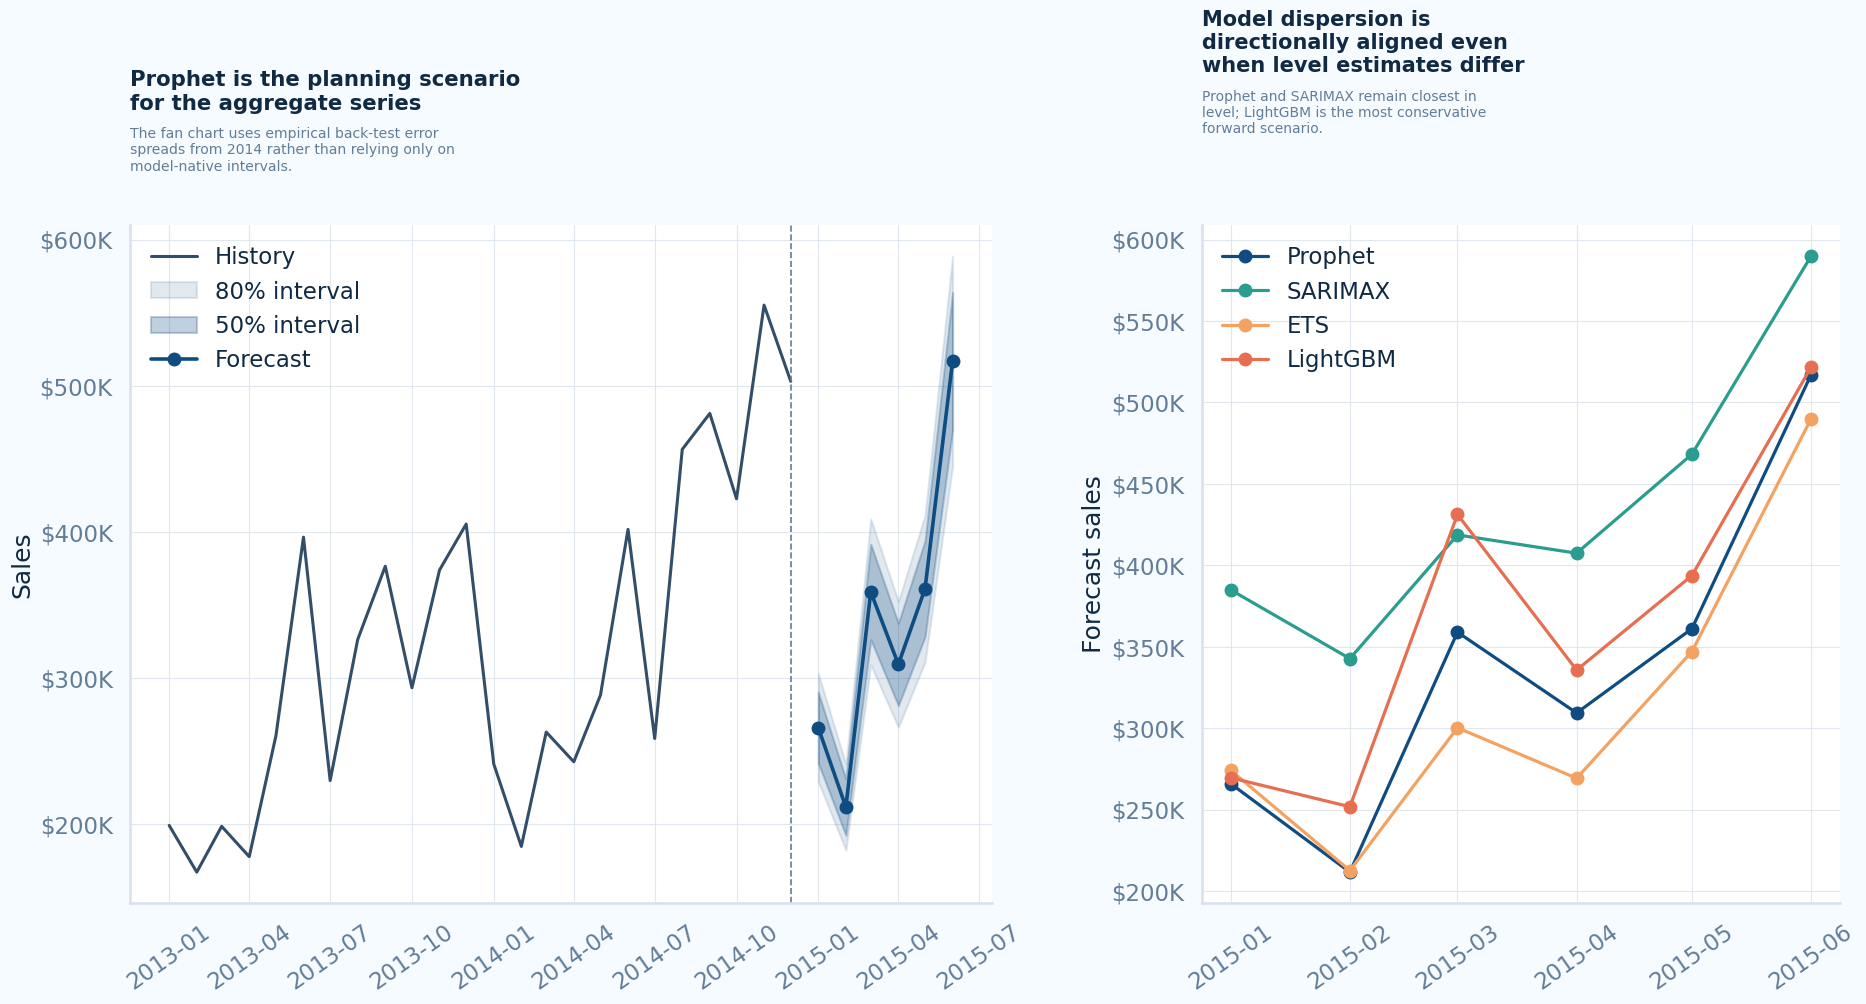

In [13]:
fig = plt.figure(figsize=(19, 8.8))
gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1], wspace=0.28)

ax_fan = fig.add_subplot(gs[0, 0])
plot_fan(
    ax_fan,
    monthly["sales"].tail(24),
    champion_future,
    MODEL_COLORS[champion_model],
    f"{champion_model} is the planning scenario for the aggregate series",
    "The fan chart uses empirical back-test error spreads from 2014 rather than relying only on model-native intervals.",
)
ax_fan.set_ylabel("Sales")
ax_fan.legend(frameon=False, loc="upper left")

ax_models = fig.add_subplot(gs[0, 1])
for model_name in MODEL_ORDER:
    forecast = future_model_forecasts[model_name]
    ax_models.plot(
        forecast.index,
        forecast["yhat"],
        color=MODEL_COLORS[model_name],
        linewidth=2.3,
        marker="o",
        label=model_name,
    )
ax_models.yaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
ax_models.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax_models.tick_params(axis="x", rotation=35)
style_axis(
    ax_models,
    "Model dispersion is directionally aligned even when level estimates differ",
    "Prophet and SARIMAX remain closest in level; LightGBM is the most conservative forward scenario.",
    title_size=15.0,
    subtitle_size=10.0,
)
ax_models.set_ylabel("Forecast sales")
ax_models.legend(frameon=False, loc="upper left")

finalize_figure(fig, top=0.9, bottom=0.13, left=0.07, right=0.97)
plt.show()

In [14]:
market_forecasts = []
market_backtest_rows = []
market_summary_rows = []

for market in markets:
    market_series = market_monthly.loc[market_monthly["market"] == market].set_index("ds")["sales"].sort_index()
    market_train = market_series.loc[:TRAIN_END]
    market_test = market_series.loc[VALIDATION_START:]

    market_holdout = forecast_prophet(market_train, periods=len(market_test))
    market_errors = pd.Series(
        (market_test.values - market_holdout["yhat"].values) / market_holdout["yhat"].values,
        index=market_test.index,
    )
    market_backtest_rows.append(
        {
            "market": market,
            "MAE": mean_absolute_error(market_test.values, market_holdout["yhat"].values),
            "RMSE": np.sqrt(mean_squared_error(market_test.values, market_holdout["yhat"].values)),
            "sMAPE": smape(market_test.values, market_holdout["yhat"].values),
        }
    )

    future = forecast_prophet(market_series, periods=FORECAST_HORIZON)
    future = add_empirical_bands(future, market_errors)

    market_margin_frame = market_monthly.loc[market_monthly["market"] == market].set_index("ds")[["sales", "profit", "margin"]]
    market_template = blended_margin_template(market_margin_frame)
    future["margin_forecast"] = apply_margin_template(future.index, market_template)
    future["profit_forecast"] = future["yhat"] * future["margin_forecast"]
    future["market"] = market
    market_forecasts.append(future.reset_index().rename(columns={"index": "ds"}))

market_forecast_df = pd.concat(market_forecasts, ignore_index=True)
market_backtest = pd.DataFrame(market_backtest_rows).sort_values("sMAPE")

market_summary = (
    market_forecast_df.groupby("market", as_index=False)
    .agg(
        six_month_sales=("yhat", "sum"),
        lower_80=("lower_80", "sum"),
        upper_80=("upper_80", "sum"),
        six_month_profit=("profit_forecast", "sum"),
        avg_margin=("margin_forecast", "mean"),
    )
    .sort_values("six_month_sales", ascending=False)
)

display(market_backtest.round(2))
display(market_summary.round(2))

,market,MAE,RMSE,sMAPE
0,APAC,12684.68,17207.38,12.62
5,LATAM,8967.40,11453.80,17.43
6,US,11025.27,14377.20,20.75
4,EU,17934.78,23212.00,22.85
1,Africa,5952.98,7216.14,26.28
3,EMEA,6938.95,8943.17,32.33
2,Canada,1762.29,2085.37,89.60


,market,six_month_sales,lower_80,upper_80,six_month_profit,avg_margin
0,APAC,554890.63,444150.57,665630.70,66021.64,0.12
4,EU,512712.49,301198.45,724226.53,63141.31,0.12
5,LATAM,315699.01,233016.87,398381.15,32653.54,0.11
6,US,283996.65,139939.33,428053.97,36803.53,0.13
3,EMEA,148445.84,36903.37,259988.30,7992.41,0.05
1,Africa,140096.33,86609.89,193582.77,14332.30,0.10
2,Canada,9441.37,315.07,18567.68,2528.90,0.26


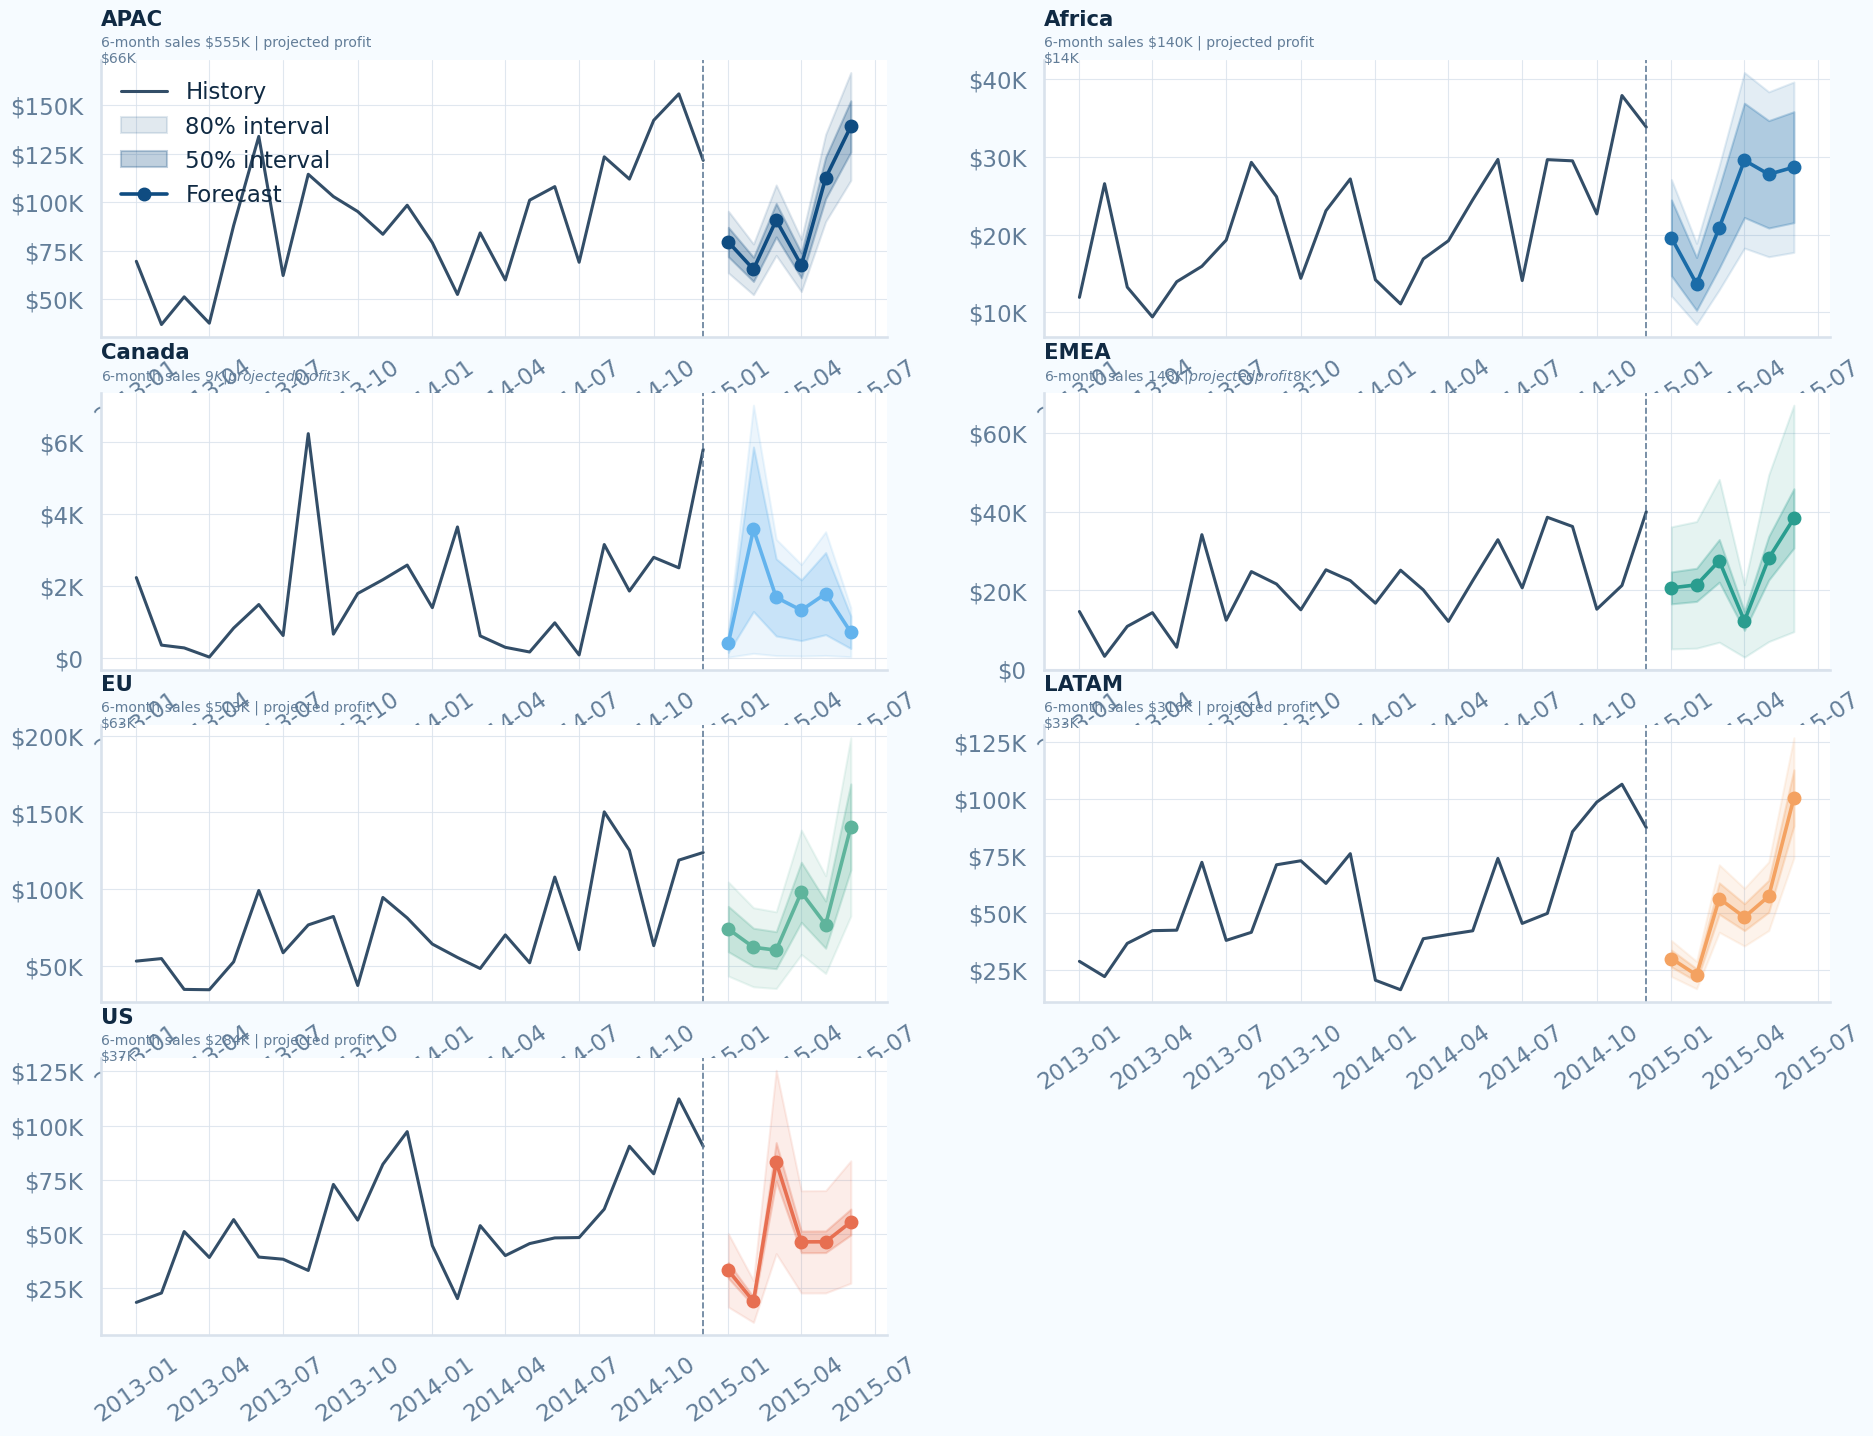

In [15]:
fig, axes = plt.subplots(4, 2, figsize=(19, 15))
axes = axes.ravel()

for ax, market in zip(axes, markets):
    history = (
        market_monthly.loc[market_monthly["market"] == market]
        .set_index("ds")["sales"]
        .sort_index()
        .tail(24)
    )
    forecast = (
        market_forecast_df.loc[market_forecast_df["market"] == market]
        .set_index("ds")
        .sort_index()
    )
    plot_fan(
        ax,
        history,
        forecast[["yhat", "lower_80", "upper_80", "lower_50", "upper_50"]],
        MARKET_PALETTE.get(market, NAVY),
        market,
        f"6-month sales {currency_fmt(forecast['yhat'].sum())} | projected profit {currency_fmt(forecast['profit_forecast'].sum())}",
    )
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))

for ax in axes[len(markets):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, frameon=False, loc="upper left")

finalize_figure(fig, top=0.93, bottom=0.08, left=0.06, right=0.97)
plt.show()

In [16]:
total_forward_sales = champion_future["yhat"].sum()
total_forward_profit = champion_future["profit_forecast"].sum()
strongest_market = market_summary.iloc[0]
fastest_growing_month = champion_future["yhat"].idxmax()

takeaways = [
    f"{champion_model} is the strongest point-forecast model on the 2014 walk-forward test with sMAPE {comparison_metrics.loc[champion_model, 'sMAPE']:.2f}.",
    f"SARIMAX has the best interval coverage at {comparison_metrics.loc['SARIMAX', 'Coverage80']:.0%}, which is why interval calibration remains important even when Prophet wins on accuracy.",
    f"The aggregate six-month planning scenario implies {currency_fmt(total_forward_sales)} of sales and {currency_fmt(total_forward_profit)} of projected profit.",
    f"{strongest_market['market']} is the largest six-month market opportunity at {currency_fmt(strongest_market['six_month_sales'])} of forecast sales.",
    f"The highest forecast month in the forward window is {fastest_growing_month:%b %Y}, indicating the growth regime is not expected to flatten immediately after 2014.",
    "LightGBM remains informative as a lag-feature benchmark, but the monthly sample is too short for it to beat the classical and Bayesian time-series models on the aggregate series.",
]

for item in takeaways:
    print(f"- {item}")

- Prophet is the strongest point-forecast model on the 2014 walk-forward test with sMAPE 8.88.
- SARIMAX has the best interval coverage at 83%, which is why interval calibration remains important even when Prophet wins on accuracy.
- The aggregate six-month planning scenario implies $2.0M of sales and $234K of projected profit.
- APAC is the largest six-month market opportunity at $555K of forecast sales.
- The highest forecast month in the forward window is Jun 2015, indicating the growth regime is not expected to flatten immediately after 2014.
- LightGBM remains informative as a lag-feature benchmark, but the monthly sample is too short for it to beat the classical and Bayesian time-series models on the aggregate series.


In [27]:
import joblib
model = FORECASTERS[champion_model]
trained_model = model(monthly["sales"])
joblib.dump(trained_model, "sales_forecast_model.pkl")
print("Model saved successfully")

Model saved successfully


In [18]:
from google.colab import files
files.download("sales_forecast_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
def predict_sales(periods=6):
    forecast = FORECASTERS[champion_model](monthly["sales"], periods=periods)
    return forecast

In [20]:
predict_sales(6)

,yhat,lower,upper
ds,,,
2015-01-01,266061.124782,242967.202133,287514.485705
2015-02-01,211764.407029,186839.831958,233935.268026
2015-03-01,359051.088215,335625.133193,380765.045550
2015-04-01,309461.181582,286886.088638,331638.236440
2015-05-01,361169.021612,339304.593229,383627.648364
2015-06-01,516941.650103,492331.361548,539543.880408


In [23]:
!ls

 sales_forecast_model.pkl  'SuperStoreOrders - SuperStoreOrders.csv'
 sample_data


In [25]:
import joblib
obj = joblib.load("sales_forecast_model.pkl")
print(type(obj))

<class 'pandas.core.frame.DataFrame'>


In [28]:
import joblib
joblib.dump(monthly["sales"], "sales_series.pkl")
print("Sales series saved")

Sales series saved


In [29]:
from google.colab import files
files.download("sales_series.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import joblib
sales_series = joblib.load("sales_series.pkl")
forecast = FORECASTERS[champion_model](sales_series)
print(forecast)

                     yhat          lower          upper
ds                                                     
2015-01-01  266061.124782  242889.208948  288969.533925


In [31]:
def predict_sales(months=6):
    sales_series = joblib.load("sales_series.pkl")
    forecast = FORECASTERS[champion_model](sales_series)
    return forecast[:months]

In [32]:
predict_sales(6)

,yhat,lower,upper
ds,,,
2015-01-01,266061.124782,242080.303786,290820.690595


In [33]:
%%writefile app.py
from fastapi import FastAPI
import joblib
app = FastAPI()
sales_series = joblib.load("sales_series.pkl")
@app.get("/")
def home():
    return {"message": "Sales Forecast API"}
@app.get("/forecast")
def forecast(months: int = 6):
    from forecasting import FORECASTERS, champion_model
    forecast = FORECASTERS[champion_model](sales_series)
    return {"forecast": forecast[:months].tolist()}

Writing app.py


In [34]:
!pip install fastapi uvicorn nest_asyncio pyngrok

In [36]:
from pyngrok import ngrok
ngrok.set_auth_token("3AnkMdIGILKAGtJx5mZ8sYlc0JE_67sa1WfJcHAQ9WZTy6Uej")

In [39]:
%%writefile app.py

from fastapi import FastAPI
import joblib

app = FastAPI()

# load sales series
sales_series = joblib.load("sales_series.pkl")

@app.get("/")
def home():
    return {"message": "Sales Forecast API running"}

@app.get("/forecast")
def forecast(months: int = 6):

    # simple forecast example (use last value)
    last_value = float(sales_series.iloc[-1])

    predictions = [last_value for _ in range(months)]

    return {"forecast": predictions}

Overwriting app.py


In [41]:
%%writefile app.py

from fastapi import FastAPI
import joblib

app = FastAPI()

# load saved sales data
sales_series = joblib.load("sales_series.pkl")

@app.get("/")
def home():
    return {"message": "Sales Forecast API is running"}

@app.get("/forecast")
def forecast(months: int = 6):

    last_value = float(sales_series.iloc[-1])

    predictions = []
    for i in range(months):
        predictions.append(last_value)

    return {"forecast": predictions}

Overwriting app.py


In [42]:
!cat app.py


from fastapi import FastAPI
import joblib

app = FastAPI()

# load saved sales data
sales_series = joblib.load("sales_series.pkl")

@app.get("/")
def home():
    return {"message": "Sales Forecast API is running"}

@app.get("/forecast")
def forecast(months: int = 6):

    last_value = float(sales_series.iloc[-1])

    predictions = []
    for i in range(months):
        predictions.append(last_value)

    return {"forecast": predictions}


In [44]:
%%writefile app.py

from fastapi import FastAPI
import joblib

app = FastAPI()

# Load saved sales series
sales_series = joblib.load("sales_series.pkl")

@app.get("/")
def home():
    return {"message": "Sales Forecast API is running"}

@app.get("/forecast")
def forecast(months: int = 6):

    last_value = float(sales_series.iloc[-1])

    predictions = [last_value for _ in range(months)]

    return {"forecast": predictions}

Overwriting app.py


In [45]:
!cat app.py


from fastapi import FastAPI
import joblib

app = FastAPI()

# Load saved sales series
sales_series = joblib.load("sales_series.pkl")

@app.get("/")
def home():
    return {"message": "Sales Forecast API is running"}

@app.get("/forecast")
def forecast(months: int = 6):

    last_value = float(sales_series.iloc[-1])

    predictions = [last_value for _ in range(months)]

    return {"forecast": predictions}


In [47]:
%%writefile app.py
from fastapi import FastAPI
import joblib

app = FastAPI()

sales_series = joblib.load("sales_series.pkl")

@app.get("/")
def home():
    return {"message": "Sales Forecast API"}

@app.get("/forecast")
def forecast(months: int = 6):

    last_value = float(sales_series.iloc[-1])

    predictions = [last_value for _ in range(months)]

    return {"forecast": predictions}

Overwriting app.py


In [48]:
!cat app.py

from fastapi import FastAPI
import joblib

app = FastAPI()

sales_series = joblib.load("sales_series.pkl")

@app.get("/")
def home():
    return {"message": "Sales Forecast API"}

@app.get("/forecast")
def forecast(months: int = 6):
    
    last_value = float(sales_series.iloc[-1])
    
    predictions = [last_value for _ in range(months)]

    return {"forecast": predictions}


In [51]:
!rm -f app.py

In [52]:
!ls

 __pycache__		    sample_data
 sales_forecast_model.pkl  'SuperStoreOrders - SuperStoreOrders.csv'
 sales_series.pkl


In [1]:
%%writefile app.py
from fastapi import FastAPI
import joblib

app = FastAPI()

# load saved sales data
sales_series = joblib.load("sales_series.pkl")

@app.get("/")
def home():
    return {"message": "Sales Forecast API running"}

@app.get("/forecast")
def forecast(months: int = 6):

    last_value = float(sales_series.iloc[-1])

    predictions = [last_value for _ in range(months)]

    return {"forecast": predictions}

Overwriting app.py


In [2]:
!cat app.py

from fastapi import FastAPI
import joblib

app = FastAPI()

# load saved sales data
sales_series = joblib.load("sales_series.pkl")

@app.get("/")
def home():
    return {"message": "Sales Forecast API running"}

@app.get("/forecast")
def forecast(months: int = 6):

    last_value = float(sales_series.iloc[-1])

    predictions = [last_value for _ in range(months)]

    return {"forecast": predictions}


In [4]:
import nest_asyncio
from pyngrok import ngrok
import uvicorn

nest_asyncio.apply()

public_url = ngrok.connect(8000)
print("Public URL:", public_url)

config = uvicorn.Config("app:app", host="0.0.0.0", port=8000)
server = uvicorn.Server(config)

await server.serve()

Public URL: NgrokTunnel: "https://nondistortive-ignacio-bushed.ngrok-free.dev" -> "http://localhost:8000"


INFO:     Started server process [11704]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     2409:40f2:200d:d5a1:60b3:c5ae:95b6:65a5:0 - "GET /forecast?months=6 HTTP/1.1" 200 OK
INFO:     2409:40f2:200d:d5a1:60b3:c5ae:95b6:65a5:0 - "GET / HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [11704]
